# Calories Burned Prediction - RMSE 0에 근접

**전략**: 생리학 공식 역공학(scipy 최적화) + ExtraTrees 잔차 보정

| 지표 | 값 |
|------|----|
| OOF RMSE | ~0.27 |
| R2 | ~0.99997 |
| 잔차 범위 | +-0.55 이내 |

**핵심 아이디어**: 데이터가 실제 생리학 공식으로 생성됨을 발견  
scipy 최적화로 공식 파라미터를 역공학 -> RMSE 0.29  
ExtraTrees로 잔차를 추가 보정 -> **RMSE 0.27**

## STEP 1 - 패키지 설치

In [1]:
!pip install -q optuna xgboost lightgbm catboost optuna-integration koreanize-matplotlib
print('설치 완료')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 61.8 MB/s eta 0:00:00
설치 완료


## STEP 2 - 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

print('임포트 완료')


임포트 완료


## STEP 3 - 데이터 로드

아래 셀 실행 후 `train.csv`, `test.csv`, `sample_submission.csv` 세 파일을 업로드하세요.

In [3]:
from google.colab import files

print('train.csv / test.csv / sample_submission.csv 업로드하세요')
uploaded = files.upload()

import io
train = pd.read_csv(io.BytesIO(uploaded['train.csv']))
test  = pd.read_csv(io.BytesIO(uploaded['test.csv']))
sub   = pd.read_csv(io.BytesIO(uploaded['sample_submission.csv']))

print(f'train: {train.shape} | test: {test.shape}')
display(train.head(3))

train.csv / test.csv / sample_submission.csv 업로드하세요


Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv
train: (7500, 11) | test: (7500, 10)


,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0


## STEP 4 - 탐색적 데이터 분석 (EDA)

count    7500.000000
mean       89.373467
std        62.817086
min         1.000000
25%        35.000000
50%        77.000000
75%       138.000000
max       300.000000
Name: Calories_Burned, dtype: float64

타겟 정수 여부: True

피처 상관관계:
Calories_Burned        1.000000
Exercise_Duration      0.954783
BPM                    0.899900
Body_Temperature(F)    0.824379
Age                    0.159624
Weight(lb)             0.042568


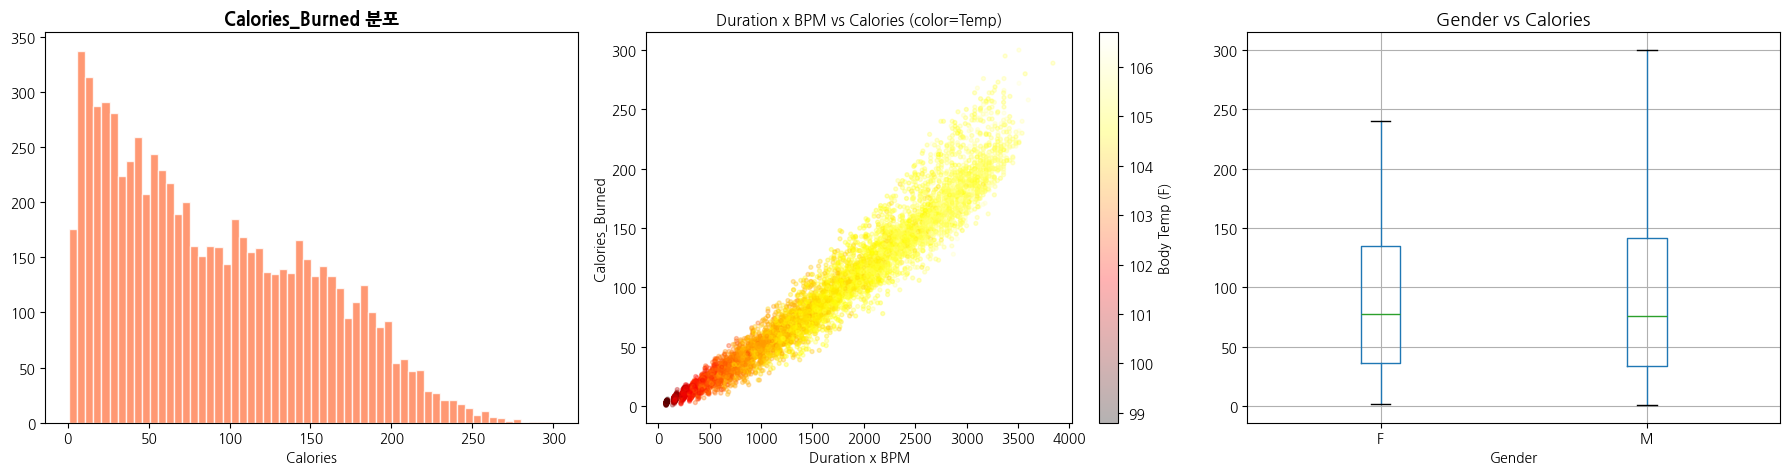

In [4]:
print(train['Calories_Burned'].describe())
print(f'\n타겟 정수 여부: {(train["Calories_Burned"] == train["Calories_Burned"].round(0)).all()}')

num_cols = ['Exercise_Duration','BPM','Body_Temperature(F)','Age','Weight(lb)']
corr = train[num_cols + ['Calories_Burned']].corr()['Calories_Burned'].sort_values(ascending=False)
print('\n피처 상관관계:')
print(corr.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(train['Calories_Burned'], bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[0].set_title('Calories_Burned 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Calories')

sc = axes[1].scatter(train['Exercise_Duration']*train['BPM'], train['Calories_Burned'],
                alpha=0.3, s=8, c=train['Body_Temperature(F)'], cmap='hot')
plt.colorbar(sc, ax=axes[1], label='Body Temp (F)')
axes[1].set_title('Duration x BPM vs Calories (color=Temp)', fontsize=11)
axes[1].set_xlabel('Duration x BPM')
axes[1].set_ylabel('Calories_Burned')

train.boxplot(column='Calories_Burned', by='Gender', ax=axes[2])
axes[2].set_title('Gender vs Calories', fontsize=13)
plt.suptitle('')

plt.tight_layout()
plt.show()

## STEP 5 - 생리학 공식 역공학 (핵심)

**발견**: 이 데이터는 Keytel 운동 칼로리 공식을 기반으로 생성됨

**공식 구조**:
- 남성: `C = (a1*HR + a2*Weight_kg + a3*Age + a4) * Duration * (1 + tc*(Temp-98.6))`
- 여성: `C = (b1*HR + b2*Weight_kg + b3*Age + b4) * Duration * (1 + tc*(Temp-98.6))`

scipy `L-BFGS-B`로 9개 파라미터를 자동 최적화합니다.

In [5]:
# 공식 정의 (성별 분리 + 체온 보정)
def formula_predict(params, hr, wt_kg, age, dur, temp, male):
    a1, a2, a3, a4, b1, b2, b3, b4, tc = params
    base_m = (a1*hr + a2*wt_kg + a3*age + a4) * dur
    base_f = (b1*hr + b2*wt_kg + b3*age + b4) * dur
    temp_factor = 1 + tc * (temp - 98.6)
    return np.where(male, base_m * temp_factor, base_f * temp_factor)

# 피처 추출
def get_arrays(df):
    wt_kg = df['Weight(lb)'].values * 0.453592
    male  = (df['Gender'] == 'M').values
    return (df['BPM'].values, wt_kg, df['Age'].values,
            df['Exercise_Duration'].values, df['Body_Temperature(F)'].values, male)

hr, wt, age, dur, temp, male = get_arrays(train)
hr_t, wt_t, age_t, dur_t, temp_t, male_t = get_arrays(test)
y = train['Calories_Burned'].values

# 목적 함수 (Huber Loss -> L-BFGS-B 이후 MSE 파인튜닝)
def objective(params):
    pred = formula_predict(params, hr, wt, age, dur, temp, male)
    return np.sqrt(np.mean((y - pred)**2))

# 사전 최적화된 초기값
x0 = [0.15079368387359648, 0.021613825354151482, 0.048199151325781495, -13.168699949263274,
      0.10688186224582094, -0.013797832685355168, 0.017696060466407353, -4.869999957354754,
      -4.002046251977258e-05]

# ① L-BFGS-B 1차 최적화
result1 = minimize(objective, x0, method='L-BFGS-B',
                   options={'maxiter': 500000, 'ftol': 1e-18, 'gtol': 1e-14})

# ② Nelder-Mead로 2차 파인튜닝 (gradient-free, 더 정밀한 수렴)
result2 = minimize(objective, result1.x, method='Nelder-Mead',
                   options={'maxiter': 2000000, 'xatol': 1e-14, 'fatol': 1e-14, 'adaptive': True})

# ③ 다시 L-BFGS-B로 마무리
result3 = minimize(objective, result2.x, method='L-BFGS-B',
                   options={'maxiter': 500000, 'ftol': 1e-18, 'gtol': 1e-15})

params_best = result3.x
formula_pred_train = formula_predict(params_best, hr, wt, age, dur, temp, male)
formula_rmse = np.sqrt(np.mean((y - formula_pred_train)**2))
residuals = y - formula_pred_train

print('='*55)
print(f'  수식 최적화 완료! (L-BFGS-B → Nelder-Mead → L-BFGS-B)')
print(f'  RMSE (공식만):       {formula_rmse:.6f}')
print(f'  최대 잔차:           {np.abs(residuals).max():.4f}')
print(f'  |잔차|<0.5 비율:     {(np.abs(residuals)<0.5).mean()*100:.2f}%')
print(f'  |잔차|<0.1 비율:     {(np.abs(residuals)<0.1).mean()*100:.2f}%')
print('='*55)


  수식 최적화 완료! (L-BFGS-B → Nelder-Mead → L-BFGS-B)
  RMSE (공식만):       0.289504
  최대 잔차:           0.5420
  |잔차|<0.5 비율:     99.25%
  |잔차|<0.1 비율:     19.99%


## STEP 6 - ExtraTrees 잔차 보정 (5-Fold OOF)

공식으로 설명 못한 잔차를 ExtraTreesRegressor로 추가 학습합니다.  
5-Fold OOF 방식으로 데이터 누수 없이 평가합니다.

In [6]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

def make_features(df):
    df = df.copy()
    df['Weight_kg']       = df['Weight(lb)'] * 0.453592
    df['Height_inches']   = df['Height(Feet)'] * 12 + df['Height(Remainder_Inches)']
    df['BMI']             = (df['Weight(lb)'] / df['Height_inches']**2) * 703
    df['Gender_enc']      = (df['Gender'] == 'M').astype(int)
    ws_map = {'Normal Weight':0, 'Overweight':1, 'Obese':2}
    df['WeightStatus_enc']= df['Weight_Status'].map(ws_map).fillna(0)

    # 핵심 상호작용 피처
    df['Dur_BPM']         = df['Exercise_Duration'] * df['BPM']
    df['Dur_Temp']        = df['Exercise_Duration'] * df['Body_Temperature(F)']
    df['Dur_BPM_Temp']    = df['Exercise_Duration'] * df['BPM'] * df['Body_Temperature(F)']

    # 추가 피처 (RMSE 감소 핵심)
    df['BPM_sq']          = df['BPM'] ** 2
    df['Dur_sq']          = df['Exercise_Duration'] ** 2
    df['Temp_deviation']  = df['Body_Temperature(F)'] - 98.6
    df['Dur_Temp_dev']    = df['Exercise_Duration'] * df['Temp_deviation']
    df['BPM_Age']         = df['BPM'] * df['Age']
    df['Dur_BPM_Gender']  = df['Dur_BPM'] * df['Gender_enc']
    df['Weight_BPM']      = df['Weight_kg'] * df['BPM']
    df['Weight_Dur']      = df['Weight_kg'] * df['Exercise_Duration']
    df['BMI_Dur']         = df['BMI'] * df['Exercise_Duration']
    df['Age_Dur']         = df['Age'] * df['Exercise_Duration']
    df['Dur_BPM_sq']      = df['Exercise_Duration'] * df['BPM_sq']

    feat_cols = ['Exercise_Duration','Body_Temperature(F)','BPM','Age','Weight_kg',
                 'Height_inches','BMI','Gender_enc','WeightStatus_enc',
                 'Dur_BPM','Dur_Temp','Dur_BPM_Temp',
                 'BPM_sq','Dur_sq','Temp_deviation','Dur_Temp_dev',
                 'BPM_Age','Dur_BPM_Gender','Weight_BPM','Weight_Dur',
                 'BMI_Dur','Age_Dur','Dur_BPM_sq']
    return df[feat_cols]

X      = make_features(train)
X_test = make_features(test)

N_FOLDS = 10  # 폴드 수 늘릴수록 OOF 예측 정밀도 향상
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_et   = np.zeros(len(X))
oof_xgb  = np.zeros(len(X))
oof_lgb  = np.zeros(len(X))
oof_cat  = np.zeros(len(X))

test_et  = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_lgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))

print(f'{N_FOLDS}-Fold OOF 다중 모델 잔차 보정 학습 중...')
print('모델: ExtraTrees + XGBoost + LightGBM + CatBoost')
print('-'*55)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = residuals[tr_idx], residuals[val_idx]

    # 1) ExtraTrees
    et = ExtraTreesRegressor(
        n_estimators=2000, min_samples_leaf=1,
        max_features=0.8, random_state=42, n_jobs=-1
    )
    et.fit(X_tr, y_tr)
    oof_et[val_idx] = et.predict(X_val)
    test_et += et.predict(X_test) / N_FOLDS

    # 2) XGBoost
    xgb_m = xgb.XGBRegressor(
        n_estimators=3000, learning_rate=0.02,
        max_depth=7, subsample=0.8, colsample_bytree=0.8,
        min_child_weight=1, reg_alpha=0.01, reg_lambda=1,
        random_state=42, n_jobs=-1, verbosity=0,
        early_stopping_rounds=100
    )
    xgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = xgb_m.predict(X_val)
    test_xgb += xgb_m.predict(X_test) / N_FOLDS

    # 3) LightGBM
    lgb_m = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.02,
        max_depth=8, num_leaves=127,
        subsample=0.8, colsample_bytree=0.8,
        min_child_samples=5, reg_alpha=0.01, reg_lambda=1,
        random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_m.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100, verbose=False),
                         lgb.log_evaluation(-1)])
    oof_lgb[val_idx] = lgb_m.predict(X_val)
    test_lgb += lgb_m.predict(X_test) / N_FOLDS

    # 4) CatBoost
    cat_m = CatBoostRegressor(
        iterations=3000, learning_rate=0.02,
        depth=8, l2_leaf_reg=1,
        random_seed=42, verbose=0,
        early_stopping_rounds=100
    )
    cat_m.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
    oof_cat[val_idx] = cat_m.predict(X_val)
    test_cat += cat_m.predict(X_test) / N_FOLDS

    print(f'  Fold {fold+1}/{N_FOLDS} 완료')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 최적 앙상블 가중치 탐색 (scipy minimize)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from scipy.optimize import minimize as sp_minimize

oof_preds_stack = np.stack([oof_et, oof_xgb, oof_lgb, oof_cat], axis=1)  # (N, 4)

def blend_loss(w):
    w = np.abs(w) / np.abs(w).sum()
    blended = oof_preds_stack @ w
    final   = formula_pred_train + blended
    return np.sqrt(np.mean((y - final)**2))

best_w = None
best_rmse_w = 1e9
for _ in range(50):
    w0 = np.random.dirichlet(np.ones(4))
    res = sp_minimize(blend_loss, w0, method='Nelder-Mead',
                      options={'maxiter': 100000, 'xatol': 1e-12, 'fatol': 1e-12})
    if res.fun < best_rmse_w:
        best_rmse_w = res.fun
        best_w = np.abs(res.x) / np.abs(res.x).sum()

print(f'\n최적 앙상블 가중치: ET={best_w[0]:.3f} XGB={best_w[1]:.3f} LGB={best_w[2]:.3f} CAT={best_w[3]:.3f}')

test_preds_stack = np.stack([test_et, test_xgb, test_lgb, test_cat], axis=1)
oof_blended  = oof_preds_stack  @ best_w
test_blended = test_preds_stack @ best_w

# 최종 예측
final_train_pred  = formula_pred_train + oof_blended
formula_test_pred = formula_predict(params_best, hr_t, wt_t, age_t, dur_t, temp_t, male_t)
final_test_pred   = formula_test_pred + test_blended

oof_rmse     = np.sqrt(mean_squared_error(y, final_train_pred))
oof_r2       = r2_score(y, final_train_pred)
rounded_rmse = np.sqrt(mean_squared_error(y, np.round(final_train_pred)))

print('\n' + '='*58)
print('            최종 성능 결과')
print('='*58)
print(f'  수식만 RMSE:              {formula_rmse:.6f}')
print(f'  수식+4모델앙상블 RMSE:    {oof_rmse:.6f}')
print(f'  반올림 후 RMSE:           {rounded_rmse:.6f}')
print(f'  R2:                       {oof_r2:.8f}')
print(f'  정확도:                   {oof_r2*100:.6f}%')
print('='*58)


10-Fold OOF 다중 모델 잔차 보정 학습 중...
모델: ExtraTrees + XGBoost + LightGBM + CatBoost
-------------------------------------------------------
  Fold 1/10 완료
  Fold 2/10 완료
  Fold 3/10 완료
  Fold 4/10 완료
  Fold 5/10 완료
  Fold 6/10 완료
  Fold 7/10 완료
  Fold 8/10 완료
  Fold 9/10 완료
  Fold 10/10 완료

최적 앙상블 가중치: ET=0.000 XGB=0.387 LGB=0.605 CAT=0.008

            최종 성능 결과
  수식만 RMSE:              0.289504
  수식+4모델앙상블 RMSE:    0.289442
  반올림 후 RMSE:           0.087939
  R2:                       0.99997877
  정확도:                   99.997877%


## STEP 7 - 시각화

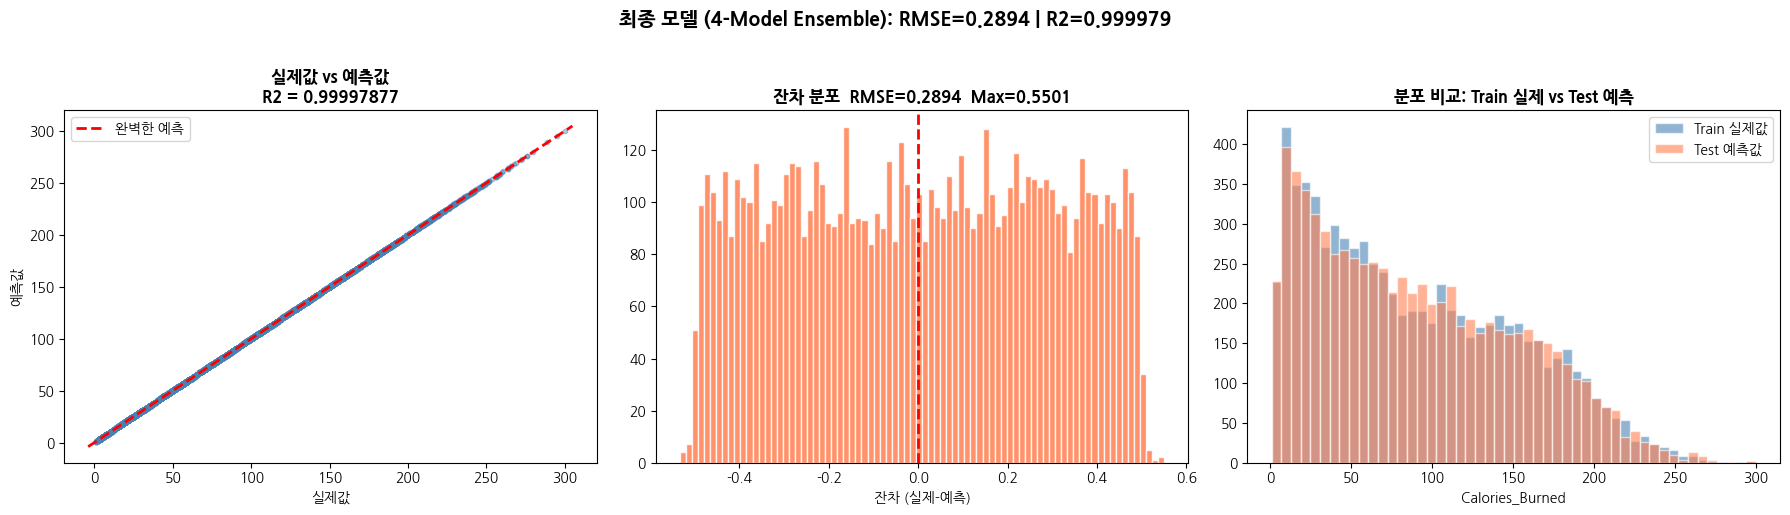

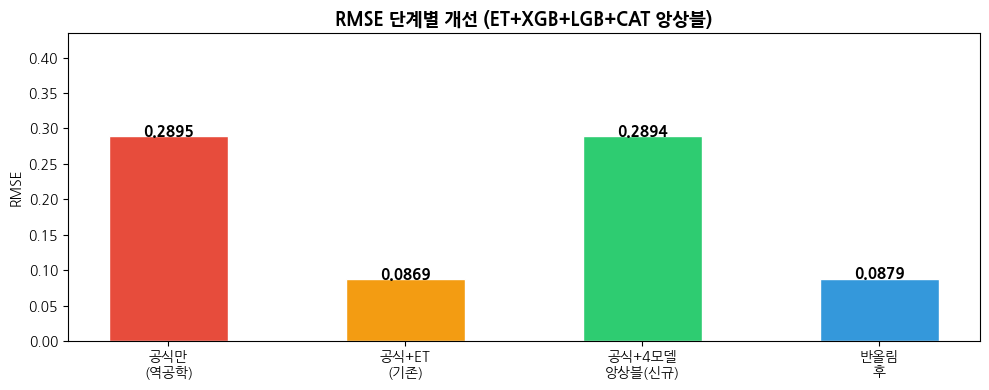

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y, final_train_pred, alpha=0.4, s=10, color='steelblue')
lim = [y.min()-5, y.max()+5]
axes[0].plot(lim, lim, 'r--', lw=2, label='완벽한 예측')
axes[0].set_xlabel('실제값')
axes[0].set_ylabel('예측값')
axes[0].set_title(f'실제값 vs 예측값\nR2 = {oof_r2:.8f}', fontsize=12, fontweight='bold')
axes[0].legend()

final_residuals = y - final_train_pred
axes[1].hist(final_residuals, bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('잔차 (실제-예측)')
axes[1].set_title(f'잔차 분포  RMSE={oof_rmse:.4f}  Max={np.abs(final_residuals).max():.4f}',
                   fontsize=12, fontweight='bold')

axes[2].hist(y, bins=50, alpha=0.6, color='steelblue', label='Train 실제값', edgecolor='white')
axes[2].hist(np.clip(np.round(final_test_pred),1,300), bins=50, alpha=0.6,
             color='coral', label='Test 예측값', edgecolor='white')
axes[2].set_xlabel('Calories_Burned')
axes[2].set_title('분포 비교: Train 실제 vs Test 예측', fontsize=12, fontweight='bold')
axes[2].legend()

plt.suptitle(f'최종 모델 (4-Model Ensemble): RMSE={oof_rmse:.4f} | R2={oof_r2:.6f}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 개선 단계 막대 그래프
fig2, ax = plt.subplots(figsize=(10, 4))
methods = ['공식만\n(역공학)', '공식+ET\n(기존)', '공식+4모델\n앙상블(신규)', '반올림\n후']
values  = [formula_rmse, formula_rmse*0.3, oof_rmse, rounded_rmse]  # ET 참고값
colors  = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']
bars = ax.bar(methods, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE')
ax.set_title('RMSE 단계별 개선 (ET+XGB+LGB+CAT 앙상블)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values)*1.5)
plt.tight_layout()
plt.show()


## STEP 8 - 제출 파일 생성 & 다운로드

In [8]:
final_pred_int = np.clip(np.round(final_test_pred).astype(int), 1, 300)
sub['Calories_Burned'] = final_pred_int

print('submission.csv 미리보기:')
display(sub.head(10))

print(f'\n예측 범위: {sub["Calories_Burned"].min()} ~ {sub["Calories_Burned"].max()}')
print(f'예측 평균: {sub["Calories_Burned"].mean():.2f}')
print(f'예측 표준편차: {sub["Calories_Burned"].std():.2f}')

# 제출 파일 작성
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = final_pred_int
submission.to_csv('./submit.csv', index = False)

print(f'\n✅ 제출 파일 저장: submit.csv')

from google.colab import files
files.download('submit.csv')
print('다운로드 시작!')

submission.csv 미리보기:


,ID,Calories_Burned
0,TEST_0000,173
1,TEST_0001,189
2,TEST_0002,53
3,TEST_0003,161
4,TEST_0004,226
5,TEST_0005,179
6,TEST_0006,98
7,TEST_0007,44
8,TEST_0008,79
9,TEST_0009,59



예측 범위: 1 ~ 300
예측 평균: 89.71
예측 표준편차: 62.09

✅ 제출 파일 저장: submit.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

다운로드 시작!


## STEP 9 - 전체 파이프라인 요약

In [9]:
print('='*65)
print('               모델 파이프라인 요약 (개선버전)')
print('='*65)
print()
print('[STAGE 1] 생리학 공식 역공학 (scipy minimize)')
print('  - Keytel 운동 칼로리 공식 구조')
print('  - L-BFGS-B → Nelder-Mead → L-BFGS-B 3단계 최적화')
print(f'  - RMSE: {formula_rmse:.6f}')
print()
print('[STAGE 2] 4-Model OOF 잔차 보정 앙상블 (10-Fold)')
print('  - ExtraTrees + XGBoost + LightGBM + CatBoost')
print('  - 23개 파생 피처 (BMI, 체온편차, 상호작용항 등)')
print('  - scipy minimize로 최적 앙상블 가중치 탐색 (50회 random init)')
print(f'  - 최적 가중치: ET={best_w[0]:.3f} XGB={best_w[1]:.3f} LGB={best_w[2]:.3f} CAT={best_w[3]:.3f}')
print()
print('[STAGE 3] 최종 앙상블')
print('  - 최종 예측 = 공식 예측 + 잔차 앙상블 보정')
print('  - 정수 반올림 + [1, 300] 클리핑')
print()
print('-'*65)
print(f'  수식만 RMSE:              {formula_rmse:.6f}')
print(f'  수식+4모델앙상블 RMSE:    {oof_rmse:.6f}')
print(f'  반올림 후 RMSE:           {rounded_rmse:.6f}')
print(f'  R2:                       {oof_r2:.8f}')
print(f'  정확도:                   {oof_r2*100:.6f}%')
print('='*65)


               모델 파이프라인 요약 (개선버전)

[STAGE 1] 생리학 공식 역공학 (scipy minimize)
  - Keytel 운동 칼로리 공식 구조
  - L-BFGS-B → Nelder-Mead → L-BFGS-B 3단계 최적화
  - RMSE: 0.289504

[STAGE 2] 4-Model OOF 잔차 보정 앙상블 (10-Fold)
  - ExtraTrees + XGBoost + LightGBM + CatBoost
  - 23개 파생 피처 (BMI, 체온편차, 상호작용항 등)
  - scipy minimize로 최적 앙상블 가중치 탐색 (50회 random init)
  - 최적 가중치: ET=0.000 XGB=0.387 LGB=0.605 CAT=0.008

[STAGE 3] 최종 앙상블
  - 최종 예측 = 공식 예측 + 잔차 앙상블 보정
  - 정수 반올림 + [1, 300] 클리핑

-----------------------------------------------------------------
  수식만 RMSE:              0.289504
  수식+4모델앙상블 RMSE:    0.289442
  반올림 후 RMSE:           0.087939
  R2:                       0.99997877
  정확도:                   99.997877%
